In [1]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver
from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE
from cycler import cycler
import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"

plt.rc('axes', prop_cycle=(cycler('color', ['tab:red', 'tab:purple',  'tab:green', 'tab:pink', 'tab:brown', 'tab:blue', 'tab:orange', 'tab:olive', 'tab:gray'])))


Solving BEKiller by using GLEE-1BEE with fixed dt=0.01


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


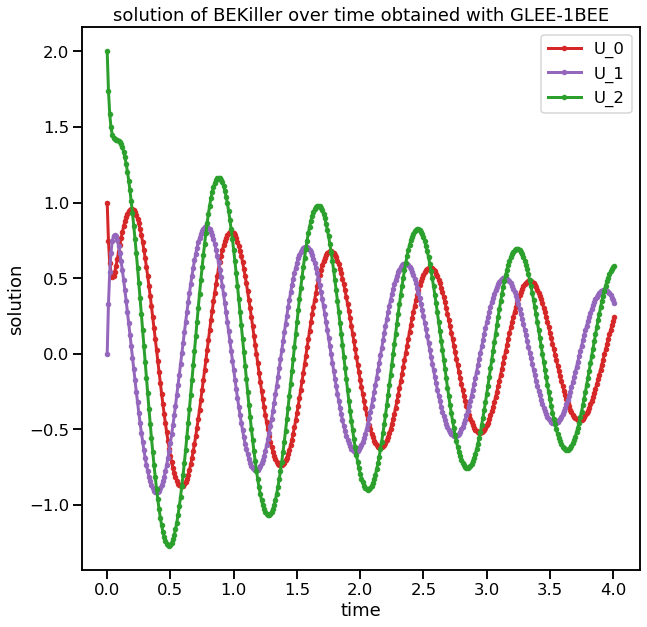

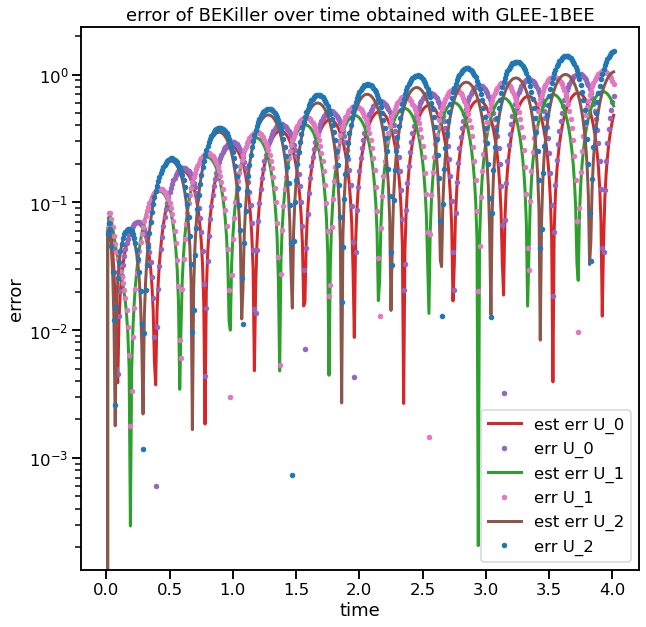

In [2]:
solver=DESolver()
solver.set_info(0)
rhs_e, rhs_i, u_ini, problem_setup, problem = ProblemsODE('BEKiller')
solver.setup()
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
solver.set_method('GLEE-1BEE')

if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)

    
problem_setup['T_DURATION']={'start':0.,'end':4.0}
problem_setup['DT']=0.01
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:} with fixed dt={:}'.format(problem_setup['name'],
                                                          solver.get_method_name(),
                                                          problem_setup['DT']))

solver.solve()

t,u,glee,_,u_h=solver.get_trajectory_GLEE()

u_exact=problem.exact_solution(t,problem_setup['context'])


fig = plt.figure(figsize=(10, 10))
for i in range(u.shape[0]):
    plt.plot(t,u[i,:],'.-', lw=3, label = 'U_{:}'.format(i))
plt.ylabel('solution')
plt.xlabel('time')
plt.legend()
plt.title('solution of {:} over time obtained with {:}'.format(problem_setup['name'],solver.get_method_name()))
plt.show()

fig = plt.figure(figsize=(10, 10))
for i in range(u.shape[0]):
    plt.semilogy(t,np.abs(glee[i,:]),'-', lw=3, label = 'est err U_{:}'.format(i))
    plt.semilogy(t,np.abs(u_exact[i,:]-u[i,:]),'.', lw=3, label = 'err U_{:}'.format(i))
    
plt.ylabel('error')
plt.xlabel('time')
plt.legend()
plt.title('error of {:} over time obtained with {:}'.format(problem_setup['name'],solver.get_method_name()))
plt.show()

In [3]:
problem_setup['context']

{'sigma': 10.0,
 'rho': 28.0,
 'beta': 2.6666666666666665,
 'data-type': numpy.float64}

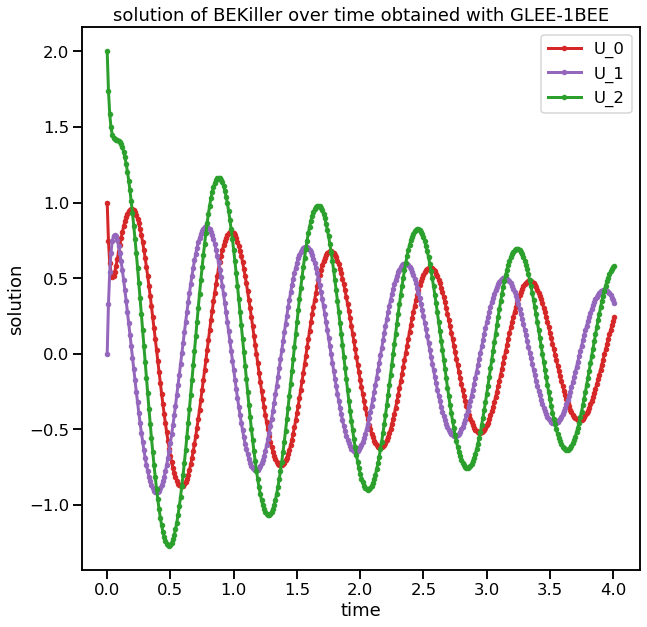

In [4]:
fig = plt.figure(figsize=(10, 10))
for i in range(u.shape[0]):
    plt.plot(t,u[i,:],'.-', lw=3, label = 'U_{:}'.format(i))
plt.ylabel('solution')
plt.xlabel('time')
plt.legend()
plt.title('solution of {:} over time obtained with {:}'.format(problem_setup['name'],solver.get_method_name()))
plt.show()

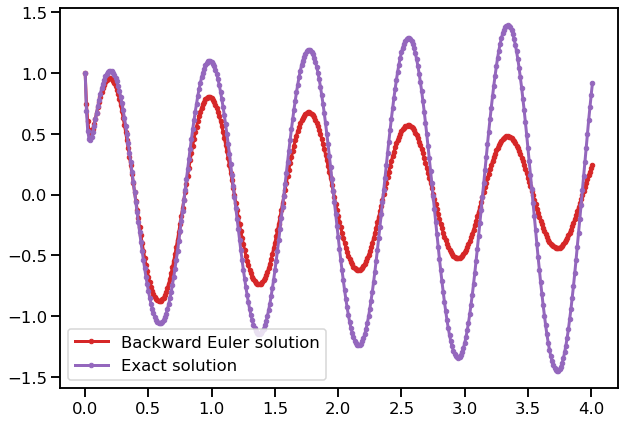

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


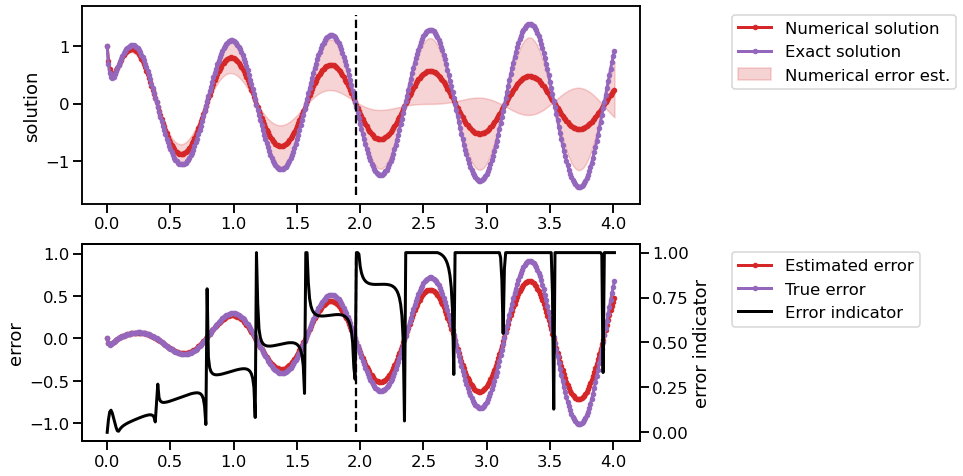

In [5]:
i=0

fig = plt.figure(figsize=(10, 7))
h=plt.plot(t,u[i,:],'.-', lw=3, label = 'Backward Euler solution')
plt.plot(t,u_exact[i,:],'.-', lw=3, label = 'Exact solution')
lgd1=plt.legend()
plt.savefig('solution.png')
plt.show()


fig = plt.figure(figsize=(10, 8))
plt.subplot(2,1,1)
h=plt.plot(t,u[i,:],'.-', lw=3, label = 'Numerical solution')
plt.plot(t,u_exact[i,:],'.-', lw=3, label = 'Exact solution')
#plt.plot(t,u_h[i,:],'.-', lw=3, label = 'UH U_{:}'.format(i))
#plt.plot(t,u[i,:]+glee[i,:],'.-', lw=3, label = 'GLEE U_{:}'.format(i))
plt.fill_between(t,u[i,:] - glee[i,:],u[i,:] + glee[i,:], alpha=0.2,color=h[0].get_color(), label = 'Numerical error est.')
plt.ylabel('solution')
#plt.xlabel('time')
lgd1=plt.legend(bbox_to_anchor=(1.15, 1), loc='upper left')
plt.plot([1.968,1.968],[plt.ylim()[0],plt.ylim()[1]],'--k')
#plt.title('solution of {:} over time obtained with {:}'.format(problem_setup['name'],solver.get_method_name()))

plt.subplot(2,1,2)

err_handle=plt.plot(t,glee[i,:],'.-', lw=3, label = 'Estimated error')
exerr_handle=plt.plot(t,-u[i,:]+u_exact[i,:],'.-', lw=3, label = 'True error')
plt.ylabel('error')
plt.plot([1.968,1.968],[plt.ylim()[0],plt.ylim()[1]],'--k')
ax2=plt.twinx()
ax2.set_ylabel('degree distance')
errind_handle=ax2.plot(t,np.minimum(np.abs(glee[i,:]/u[i,:]),1.),'k-', lw=3, label = 'Error indicator')
plt.ylabel('error indicator')
plt.xlabel('time')
lgd2=plt.legend([err_handle[0],exerr_handle[0],errind_handle[0]],
           [err_handle[0].get_label(),exerr_handle[0].get_label(),errind_handle[0].get_label()],bbox_to_anchor=(1.15, 1), loc='upper left')
plt.savefig('Error.png', bbox_extra_artists=(lgd1,lgd2), bbox_inches='tight')
plt.savefig('Error.eps', bbox_extra_artists=(lgd1,lgd2), bbox_inches='tight')
plt.show()